# Partial Least Squares Regression (PLS)

In [ ]:

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

from pathlib import Path
PROJECT = Path('/content/drive/MyDrive/MSC THESIS')
DATA_DIR = PROJECT / 'ml_dataset' / 'data' / 'model_ready' / 'movie_success_v6'
RUN_DIR = DATA_DIR / 'colab_runs_v2'
RUN_DIR.mkdir(parents=True, exist_ok=True)

for f in ['movie_features_v6.csv', 'movie_features_v6_synthetic.csv',
          'scene_movie_metadata_v6.csv', 'scene_movie_metadata_v6_synthetic.csv']:
    assert (DATA_DIR / f).exists(), f'Missing: {f}'
print('Data dir:', DATA_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data dir: /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6


In [15]:
import warnings; warnings.filterwarnings('ignore')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    LeaveOneOut, KFold, GridSearchCV, cross_val_predict,
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
)
from scipy.stats import spearmanr, pearsonr

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
print('Imports OK')

Imports OK


# Data loading

In [ ]:

real_mov  = pd.read_csv(DATA_DIR / 'movie_features_v6.csv')
syn_mov   = pd.read_csv(DATA_DIR / 'movie_features_v6_synthetic.csv')
real_meta = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6.csv')
syn_meta  = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6_synthetic.csv')


LEAKAGE_AND_OLD_TARGETS = [
    'budget_usd', 'revenue_usd', 'roi_percent', 'success_class',
    'imdb_rating', 'wom_multiplier', 'wom_multiplier_log',
]
real_mov = real_mov.drop(columns=LEAKAGE_AND_OLD_TARGETS, errors='ignore')
syn_mov  = syn_mov.drop(columns=LEAKAGE_AND_OLD_TARGETS, errors='ignore')

# Columns from metadata to use as features (excluding IDs, text, leakage)
META_KEEP = [
    'movie_id',
    # Scene properties (will be encoded below)
    'targeted_emotion', 'clip_duration_s',
    'cut_count', 'brightness', 'motion_intensity', 'audio_loudness',
    'silence_ratio', 'music_presence', 'dialogue_density',
    'face_screen_time_ratio', 'lead_screen_time_ratio',
    # Movie metadata
    'release_year', 'genre_primary', 'genre_secondary',
    'country_of_origin', 'budget_categorical',
    # Targets (kept to extract y; not used as features)
    'imdb_rating', 'wom_multiplier', 'wom_multiplier_log',
]
real_meta_sub = real_meta[[c for c in META_KEEP if c in real_meta.columns]]
syn_meta_sub  = syn_meta[[c for c in META_KEEP if c in syn_meta.columns]]

real_mov = real_mov.merge(real_meta_sub, on='movie_id', how='left')
real_mov['is_synthetic'] = 0
syn_mov = syn_mov.merge(syn_meta_sub, on='movie_id', how='left')
syn_mov['is_synthetic'] = 1

df_all = pd.concat([real_mov, syn_mov], ignore_index=True)
print(f'Real:      {len(real_mov)} movies')
print(f'Synthetic: {len(syn_mov)} movies')
print(f'Combined:  {len(df_all)} movies × {len(df_all.columns)} columns (pre-encoding)')
print()
print('Target distributions (pre-encoding):')
display(df_all[['is_synthetic', 'imdb_rating', 'wom_multiplier_log']]
        .groupby('is_synthetic').describe().round(2))

Real:      10 movies
Synthetic: 40 movies
Combined:  50 movies × 343 columns (pre-encoding)

Target distributions (pre-encoding):


imdb_rating                                        wom_multiplier_log                                          
                   count  mean   std  min  25%   50%   75%  max              count  mean   std   min   25%   50%   75%   max
is_synthetic                                                                                                                
0                   10.0  7.41  0.73  6.5  6.8  7.45  8.02  8.5               10.0  1.77  0.64  0.75  1.28  1.88  2.21  2.73
1                   40.0  7.48  0.55  6.5  7.0  7.50  7.82  8.4               40.0  1.70  0.54  0.34  1.28  1.86  2.04  2.91

## 3 · Feature preparation

In [ ]:

DROP = {
    'movie_id', 'condition', 'n_participants',
    # Targets (cannot be features)
    'imdb_rating', 'wom_multiplier', 'wom_multiplier_log',
    # Control flag (not a feature)
    'is_synthetic',
}

df_feat = df_all.copy()

# Ordinal encoding: low / moderate / high → 1 / 2 / 3
ORD_MAP = {'low': 1, 'moderate': 2, 'high': 3}
ORD_COLS = ['cut_count', 'brightness', 'motion_intensity', 'audio_loudness',
            'silence_ratio', 'music_presence', 'dialogue_density',
            'face_screen_time_ratio', 'lead_screen_time_ratio',
            'budget_categorical']
for c in ORD_COLS:
    if c in df_feat.columns:
        df_feat[c] = df_feat[c].map(ORD_MAP)

# One-hot encode multi-category text columns
OH_COLS = ['targeted_emotion', 'genre_primary', 'genre_secondary', 'country_of_origin']
OH_COLS = [c for c in OH_COLS if c in df_feat.columns]
df_feat = pd.get_dummies(df_feat, columns=OH_COLS, prefix_sep='_',
                         dummy_na=False, dtype=int)

# Build feature matrix
feature_cols = [c for c in df_feat.columns if c not in DROP]
X_all = df_feat[feature_cols].apply(pd.to_numeric, errors='coerce')
y_imdb_all = df_feat['imdb_rating'].astype(float)
y_wom_all  = df_feat['wom_multiplier_log'].astype(float)
groups_all = df_feat['movie_id'].values if 'movie_id' in df_feat.columns else np.arange(len(df_feat))
synth_mask_all = df_feat['is_synthetic'].values.astype(bool)

# Drop all-NaN columns
all_nan_cols = X_all.columns[X_all.isna().all()].tolist()
if all_nan_cols:
    print(f'Dropping {len(all_nan_cols)} all-NaN columns')
    X_all = X_all.drop(columns=all_nan_cols)

# Drop zero-variance columns
zero_var_cols = X_all.columns[X_all.std() == 0].tolist()
if zero_var_cols:
    print(f'Dropping {len(zero_var_cols)} zero-variance columns')
    X_all = X_all.drop(columns=zero_var_cols)

feature_cols = list(X_all.columns)

# Categorise final features for transparency
phys_cols = [c for c in feature_cols if c.endswith('__mean') or c.endswith('__std')]
ord_in_X  = [c for c in feature_cols if c in ORD_COLS]
oh_in_X   = [c for c in feature_cols
             if any(c.startswith(p + '_') for p in
                    ['targeted_emotion', 'genre_primary', 'genre_secondary',
                     'country_of_origin'])]
other_cols = [c for c in feature_cols
              if c not in phys_cols + ord_in_X + oh_in_X]

print(f'\nFinal feature matrix: {X_all.shape}')
print(f'  Physiological (mean/std):  {len(phys_cols):>4d}')
print(f'  Scene/movie ordinal:       {len(ord_in_X):>4d}  ({ord_in_X})')
print(f'  Scene/movie one-hot:       {len(oh_in_X):>4d}')
print(f'  Other numeric (year, dur): {len(other_cols):>4d}  ({other_cols})')
print(f'  TOTAL features:            {len(feature_cols):>4d}')


Final feature matrix: (50, 360)
  Physiological (mean/std):   320
  Scene/movie ordinal:         10  (['cut_count', 'brightness', 'motion_intensity', 'audio_loudness', 'silence_ratio', 'music_presence', 'dialogue_density', 'face_screen_time_ratio', 'lead_screen_time_ratio', 'budget_categorical'])
  Scene/movie one-hot:         28
  Other numeric (year, dur):    2  (['clip_duration_s', 'release_year'])
  TOTAL features:             360


# Evaluation helpers

In [18]:
def regression_metrics(y_true, y_pred):
    mask = ~(np.isnan(y_pred) | np.isnan(y_true))
    yt, yp = np.asarray(y_true)[mask], np.asarray(y_pred)[mask]
    if len(yt) < 3:
        return {'n': len(yt), 'r2': np.nan, 'mae': np.nan, 'rmse': np.nan,
                'spearman': np.nan, 'pearson': np.nan}
    return {
        'n': len(yt),
        'r2': r2_score(yt, yp),
        'mae': mean_absolute_error(yt, yp),
        'rmse': np.sqrt(mean_squared_error(yt, yp)),
        'spearman': spearmanr(yt, yp).correlation,
        'pearson': pearsonr(yt, yp)[0],
    }

def loo_predict(estimator, X, y):
    return cross_val_predict(estimator, X, y, cv=LeaveOneOut(), n_jobs=-1)

def kfold_predict(estimator, X, y, n_splits=5, random_state=42):
    return cross_val_predict(estimator, X, y,
                            cv=KFold(n_splits=n_splits, shuffle=True,
                                    random_state=random_state),
                            n_jobs=-1)

def report(metrics, title=''):
    print(f'\n──── {title} ────')
    for k, v in metrics.items():
        if k == 'n': print(f'  {k:>10s}: {v}')
        else: print(f'  {k:>10s}: {v:.3f}' if not np.isnan(v) else f'  {k:>10s}: NaN')

def plot_pred_vs_actual(y_true, y_pred, title, ax=None, y_std=None):
    if ax is None: fig, ax = plt.subplots(figsize=(5, 5))
    mask = ~(np.isnan(y_pred) | np.isnan(y_true))
    yt, yp = np.asarray(y_true)[mask], np.asarray(y_pred)[mask]
    if y_std is not None:
        ys = np.asarray(y_std)[mask]
        ax.errorbar(yt, yp, yerr=ys, fmt='o', alpha=0.6,
                    capsize=2, ecolor='gray', markersize=6)
    else:
        ax.scatter(yt, yp, alpha=0.6, s=40, edgecolor='k', linewidth=0.5)
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], 'r--', alpha=0.5, label='y = x')
    r2 = r2_score(yt, yp)
    rho = spearmanr(yt, yp).correlation
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(f'{title}\nR²={r2:.2f}, Spearman ρ={rho:.2f}')
    ax.legend(); ax.grid(alpha=0.3)
    return ax

# Real-only (LOO CV, n = 10)

In [ ]:
from sklearn.cross_decomposition import PLSRegression

mask_real = ~synth_mask_all
X_real = X_all[mask_real].reset_index(drop=True)
y_imdb_real = y_imdb_all[mask_real].reset_index(drop=True)
y_wom_real = y_wom_all[mask_real].reset_index(drop=True)

def make_pls_pipeline(n_components=2):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', PLSRegression(n_components=n_components, scale=False)),
    ])

# Baseline: 2 components
pipe = make_pls_pipeline(n_components=2)
y_pred = loo_predict(pipe, X_real, y_imdb_real)
metrics_real_imdb_baseline = regression_metrics(y_imdb_real, y_pred)
report(metrics_real_imdb_baseline, 'Real / IMDb / baseline (n_comp=2)')

pipe = make_pls_pipeline(n_components=2)
y_pred = loo_predict(pipe, X_real, y_wom_real)
metrics_real_wom_baseline = regression_metrics(y_wom_real, y_pred)
report(metrics_real_wom_baseline, 'Real / WOM / baseline (n_comp=2)')


──── Real / IMDb / baseline (n_comp=2) ────
           n: 10
          r2: -1.045
         mae: 0.914
        rmse: 0.996
    spearman: -0.701
     pearson: -0.683

──── Real / WOM / baseline (n_comp=2) ────
           n: 10
          r2: -0.846
         mae: 0.740
        rmse: 0.821
    spearman: -0.770
     pearson: -0.710


### 5b · Tuning n_components (LOO CV)

In [ ]:
# With n=10 training, n_components must be less than n_train - 1 = 9.
# Constrain to small values to avoid overfitting.
param_grid_real = {'model__n_components': [1, 2, 3, 4, 5]}

search = GridSearchCV(make_pls_pipeline(), param_grid_real,
                     cv=LeaveOneOut(), scoring='neg_mean_absolute_error',
                     n_jobs=-1, refit=True)
search.fit(X_real, y_imdb_real)
best_params_imdb_real = search.best_params_
y_pred_real_imdb_tuned = loo_predict(search.best_estimator_, X_real, y_imdb_real)
metrics_real_imdb_tuned = regression_metrics(y_imdb_real, y_pred_real_imdb_tuned)
print(f'\nBest IMDb params: {best_params_imdb_real}')
report(metrics_real_imdb_tuned, 'Real / IMDb / tuned')

search = GridSearchCV(make_pls_pipeline(), param_grid_real,
                     cv=LeaveOneOut(), scoring='neg_mean_absolute_error',
                     n_jobs=-1, refit=True)
search.fit(X_real, y_wom_real)
best_params_wom_real = search.best_params_
y_pred_real_wom_tuned = loo_predict(search.best_estimator_, X_real, y_wom_real)
metrics_real_wom_tuned = regression_metrics(y_wom_real, y_pred_real_wom_tuned)
print(f'\nBest WOM params: {best_params_wom_real}')
report(metrics_real_wom_tuned, 'Real / WOM / tuned')


Best IMDb params: {'model__n_components': 5}

──── Real / IMDb / tuned ────
           n: 10
          r2: -0.975
         mae: 0.898
        rmse: 0.979
    spearman: -0.713
     pearson: -0.677

Best WOM params: {'model__n_components': 1}

──── Real / WOM / tuned ────
           n: 10
          r2: -0.866
         mae: 0.711
        rmse: 0.825
    spearman: -0.782
     pearson: -0.760


# Augmented (5-fold CV, n = 50)

In [21]:
# Augmented — wider n_components search (1..20)
param_grid_aug = {'model__n_components': list(range(1, 21))}

search = GridSearchCV(make_pls_pipeline(), param_grid_aug,
                     cv=KFold(n_splits=5, shuffle=True, random_state=42),
                     scoring='neg_mean_absolute_error', n_jobs=-1, refit=True)
search.fit(X_all, y_imdb_all)
best_params_imdb = search.best_params_
y_pred_aug_imdb_tuned = kfold_predict(search.best_estimator_, X_all, y_imdb_all, n_splits=5)
metrics_aug_imdb_tuned = regression_metrics(y_imdb_all, y_pred_aug_imdb_tuned)
print(f'\nBest IMDb params: {best_params_imdb}')
report(metrics_aug_imdb_tuned, 'Augmented / IMDb / tuned')

search = GridSearchCV(make_pls_pipeline(), param_grid_aug,
                     cv=KFold(n_splits=5, shuffle=True, random_state=42),
                     scoring='neg_mean_absolute_error', n_jobs=-1, refit=True)
search.fit(X_all, y_wom_all)
best_params_wom = search.best_params_
y_pred_aug_wom_tuned = kfold_predict(search.best_estimator_, X_all, y_wom_all, n_splits=5)
metrics_aug_wom_tuned = regression_metrics(y_wom_all, y_pred_aug_wom_tuned)
print(f'\nBest WOM params: {best_params_wom}')
report(metrics_aug_wom_tuned, 'Augmented / WOM / tuned')


Best IMDb params: {'model__n_components': 2}

──── Augmented / IMDb / tuned ────
           n: 50
          r2: 0.472
         mae: 0.309
        rmse: 0.418
    spearman: 0.680
     pearson: 0.689

Best WOM params: {'model__n_components': 1}

──── Augmented / WOM / tuned ────
           n: 50
          r2: 0.190
         mae: 0.402
        rmse: 0.494
    spearman: 0.385
     pearson: 0.461


In [22]:
# Tuned
search = GridSearchCV(make_pls_pipeline(), param_grid_aug,
                     cv=KFold(n_splits=5, shuffle=True, random_state=42),
                     scoring='neg_mean_absolute_error', n_jobs=-1, refit=True)
search.fit(X_all, y_imdb_all)
best_params_imdb = search.best_params_
y_pred_aug_imdb_tuned = kfold_predict(search.best_estimator_, X_all, y_imdb_all, n_splits=5)
metrics_aug_imdb_tuned = regression_metrics(y_imdb_all, y_pred_aug_imdb_tuned)
print(f'\nBest IMDb params: {best_params_imdb}')
report(metrics_aug_imdb_tuned, 'Augmented / IMDb / tuned')

search = GridSearchCV(make_pls_pipeline(), param_grid_aug,
                     cv=KFold(n_splits=5, shuffle=True, random_state=42),
                     scoring='neg_mean_absolute_error', n_jobs=-1, refit=True)
search.fit(X_all, y_wom_all)
best_params_wom = search.best_params_
y_pred_aug_wom_tuned = kfold_predict(search.best_estimator_, X_all, y_wom_all, n_splits=5)
metrics_aug_wom_tuned = regression_metrics(y_wom_all, y_pred_aug_wom_tuned)
print(f'\nBest WOM params: {best_params_wom}')
report(metrics_aug_wom_tuned, 'Augmented / WOM / tuned')


Best IMDb params: {'model__n_components': 2}

──── Augmented / IMDb / tuned ────
           n: 50
          r2: 0.472
         mae: 0.309
        rmse: 0.418
    spearman: 0.680
     pearson: 0.689

Best WOM params: {'model__n_components': 1}

──── Augmented / WOM / tuned ────
           n: 50
          r2: 0.190
         mae: 0.402
        rmse: 0.494
    spearman: 0.385
     pearson: 0.461


# Visuals

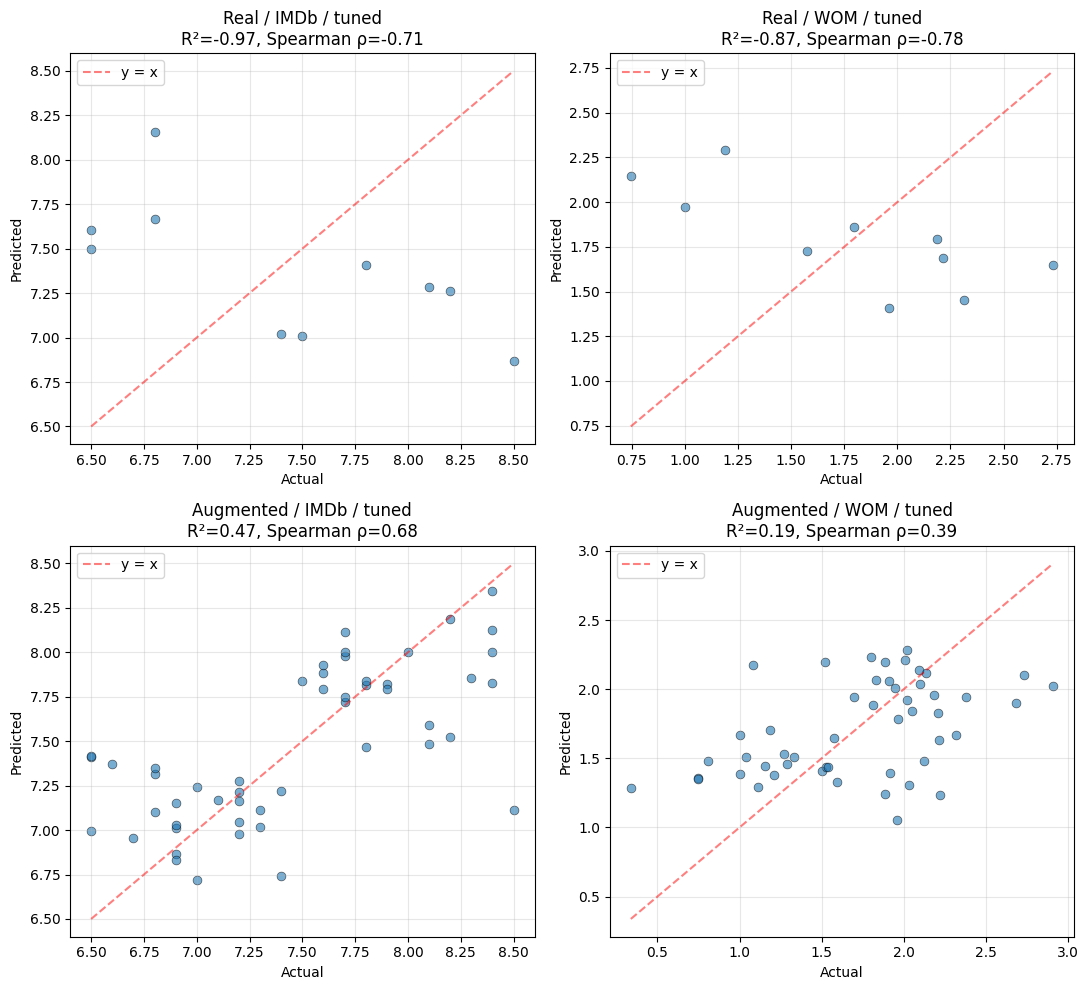

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
plot_pred_vs_actual(y_imdb_real, y_pred_real_imdb_tuned,
                    'Real / IMDb / tuned', axes[0, 0])
plot_pred_vs_actual(y_wom_real, y_pred_real_wom_tuned,
                    'Real / WOM / tuned', axes[0, 1])
plot_pred_vs_actual(y_imdb_all, y_pred_aug_imdb_tuned,
                    'Augmented / IMDb / tuned', axes[1, 0])
plot_pred_vs_actual(y_wom_all, y_pred_aug_wom_tuned,
                    'Augmented / WOM / tuned', axes[1, 1])
plt.tight_layout(); plt.show()

# PLS components: variance


In [24]:
# Refit on full augmented data with best n_components for IMDb
n_comp = best_params_imdb['model__n_components']
final_pipe = make_pls_pipeline(n_components=n_comp)
final_pipe.fit(X_all, y_imdb_all)
pls = final_pipe.named_steps['model']

# Variance explained per component
# x_scores has shape (n_samples, n_comp). Total variance = sum of squares.
X_imp = final_pipe.named_steps['imputer'].transform(X_all)
X_sc  = final_pipe.named_steps['scaler'].transform(X_imp)
total_var_X = (X_sc ** 2).sum()
var_per_comp_X = ((pls.x_scores_) ** 2).sum(axis=0) / total_var_X * 100

total_var_Y = ((y_imdb_all - y_imdb_all.mean()) ** 2).sum()
var_per_comp_Y = ((pls.y_scores_) ** 2).sum(axis=0) / total_var_Y * 100

print(f'PLS components: {n_comp}')
print(f'\n  Component   Var(X) %   Var(Y) %   Cum Var(Y) %')
print('─' * 50)
cum = 0
for i in range(n_comp):
    cum += var_per_comp_Y[i]
    print(f'  PC{i+1:>3d}      {var_per_comp_X[i]:>7.2f}    '
          f'{var_per_comp_Y[i]:>7.2f}    {cum:>7.2f}')

# Top features per component (loadings)
loadings = pls.x_loadings_      # (n_features, n_comp)
print(f'\nTop 15 features for each component:')
for c in range(min(n_comp, 3)):  # Show first 3 components
    idx = np.argsort(np.abs(loadings[:, c]))[::-1][:15]
    print(f'\n  Component {c+1}:')
    for i in idx:
        print(f'    {feature_cols[i]:<40s}  loading = {loadings[i, c]:>+.4f}')

PLS components: 2

  Component   Var(X) %   Var(Y) %   Cum Var(Y) %
──────────────────────────────────────────────────
  PC  1        10.80    16893.29    16893.29
  PC  2         3.41    5453.91    22347.20

Top 15 features for each component:

  Component 1:
    sr_emo_bc_disgust__std                    loading = +0.1398
    sr_emo_disgust__std                       loading = +0.1394
    emp_hr_reactivity__mean                   loading = -0.1375
    movie_familiarity__std                    loading = +0.1288
    sr_emo_disgust__mean                      loading = +0.1257
    sr_emo_bc_disgust__mean                   loading = +0.1245
    sr_emo_anger__std                         loading = +0.1211
    movie_familiarity__mean                   loading = +0.1205
    sr_emo_amusement__std                     loading = +0.1204
    eeg_alpha_asym_buildup__std               loading = +0.1171
    q_disgust_max__mean                       loading = +0.1156
    q_head_yaw_std__mean           

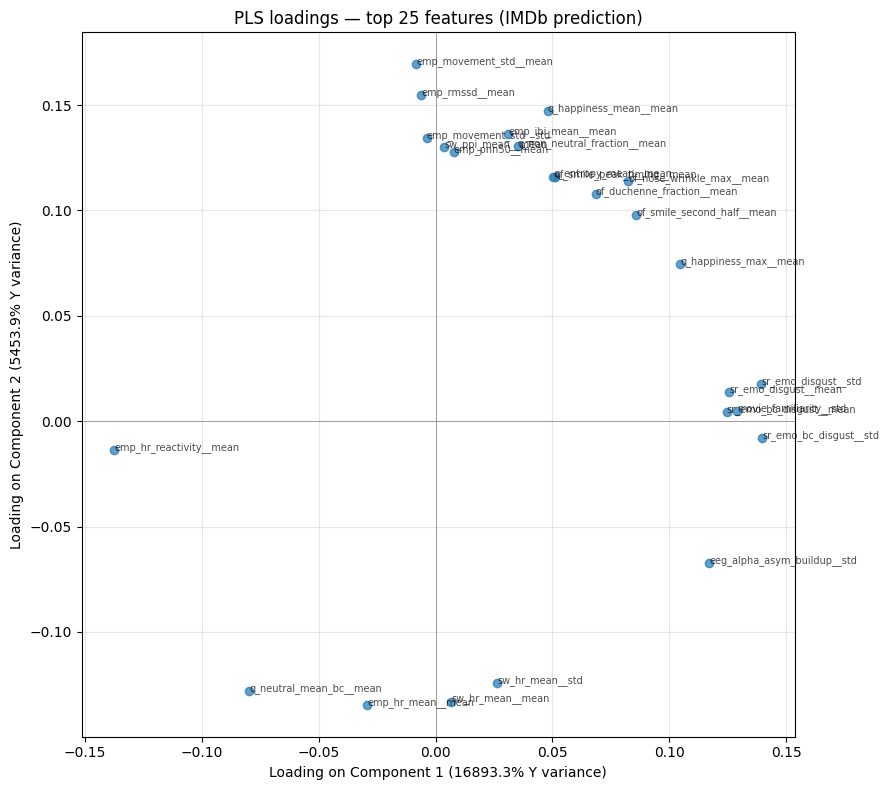

In [ ]:
# Visualise loadings on the first 2 components
fig, ax = plt.subplots(figsize=(9, 8))
top_n = 25
top_idx = np.argsort(np.linalg.norm(loadings[:, :2], axis=1))[::-1][:top_n]
ax.scatter(loadings[top_idx, 0], loadings[top_idx, 1], alpha=0.7)
for i in top_idx:
    ax.annotate(feature_cols[i][:30], (loadings[i, 0], loadings[i, 1]),
                fontsize=7, alpha=0.7)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel(f'Loading on Component 1 ({var_per_comp_Y[0]:.1f}% Y variance)')
ax.set_ylabel(f'Loading on Component 2 ({var_per_comp_Y[1]:.1f}% Y variance)')
ax.set_title('PLS loadings — top 25 features (IMDb prediction)')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [26]:
out_path = RUN_DIR / 'results_pls.json'
results_to_save = {
    'model': 'pls',
    'feature_count': len(feature_cols),
    'best_params_imdb': best_params_imdb,
    'best_params_wom':  best_params_wom,
    'metrics_real_imdb_baseline': metrics_real_imdb_baseline,
    'metrics_real_wom_baseline':  metrics_real_wom_baseline,
    'metrics_real_imdb_tuned':    metrics_real_imdb_tuned,
    'metrics_real_wom_tuned':     metrics_real_wom_tuned,
    'metrics_aug_imdb_baseline':  metrics_aug_imdb_baseline,
    'metrics_aug_wom_baseline':   metrics_aug_wom_baseline,
    'metrics_aug_imdb_tuned':     metrics_aug_imdb_tuned,
    'metrics_aug_wom_tuned':      metrics_aug_wom_tuned,
}
with open(out_path, 'w') as f:
    json.dump(results_to_save, f, indent=2, default=str)
print(f'Saved → {out_path}')

Saved → /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6/colab_runs_v2/results_pls.json
